In [1]:
#Example:
""" import pandas as pd
data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}
df_skill_list = pd.DataFrame(data)
df_skill_list.explode('job_skills').value_counts('job_skills').plot(kind='bar')
 """

" import pandas as pd\ndata = {\n    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],\n    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]\n}\ndf_skill_list = pd.DataFrame(data)\ndf_skill_list.explode('job_skills').value_counts('job_skills').plot(kind='bar')\n "

In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

c:\Users\Ryan\anaconda3\envs\pyp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: xlabel='job_skills'>

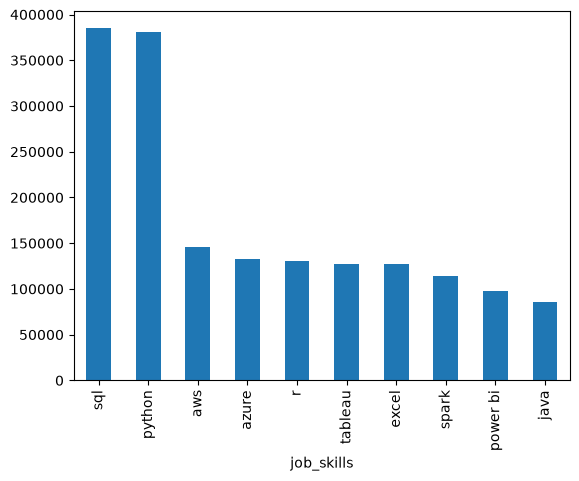

In [9]:
df_exploded = df.explode('job_skills')
df_exploded.value_counts('job_skills').head(10).plot(kind='bar')

In [26]:
df_counts = df_exploded.groupby(['job_title_short', 'job_skills']).size().reset_index(name='job_counts').sort_values(by='job_counts', ascending=False)

In [27]:
df_counts.head(3)

,job_title_short,job_skills,job_counts
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022


In [31]:
job_title = 'Data Analyst'
top = 10
df_final = df_counts[df_counts['job_title_short'] == job_title].head(top)
df_final

,job_title_short,job_skills,job_counts
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


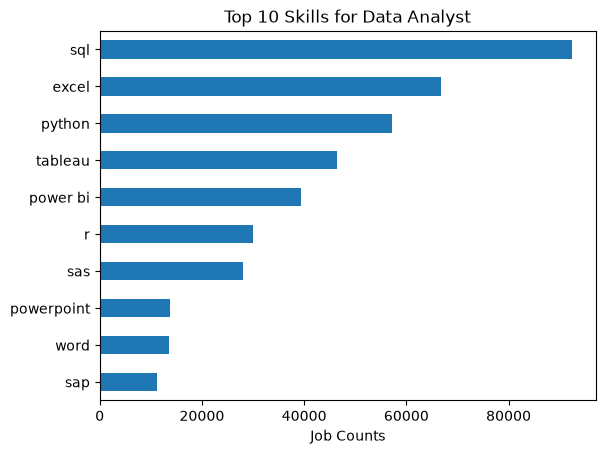

In [42]:
df_final.plot(kind='barh', x='job_skills', y='job_counts')
plt.gca().invert_yaxis()
plt.title(f'Top {top} Skills for {job_title}')
plt.xlabel('Job Counts')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()

In [47]:
df_counts = df.explode('job_skills').groupby(['job_title_short', 'job_skills']).size().reset_index(name='job_counts').sort_values(by='job_counts', ascending=False)
df_counts

,job_title_short,job_skills,job_counts
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


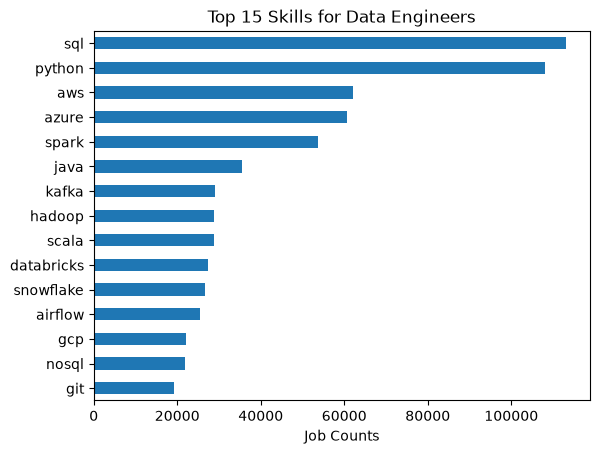

In [50]:
job_title = 'Data Engineer'
top = 15
df_final = df_counts[df_counts['job_title_short'] == job_title].head(top)
df_final.plot(kind='barh', y='job_counts', x='job_skills')
plt.gca().invert_yaxis()
plt.title(f'Top {top} Skills for {job_title}s')
plt.xlabel('Job Counts')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()

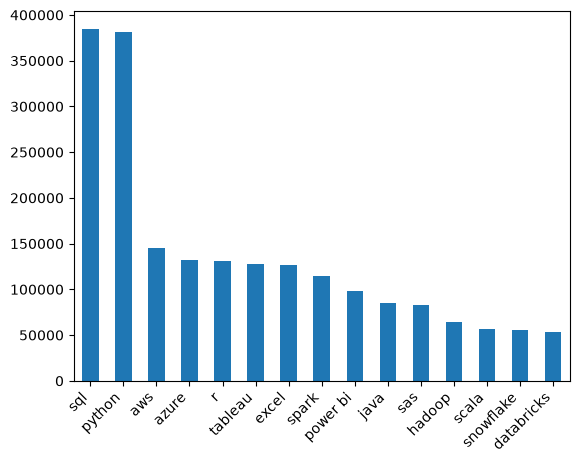

In [56]:
df.explode('job_skills').value_counts('job_skills').head(15).plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.show()